# EfficientNet-B0 - Individual Baseline Run


In [1]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import EfficientNetB0
from data import prepare_full_dataframe, prepare_data, sample_image_path, get_transforms
from train import run_training_pipeline, run_smoke_test
from train_eval import evaluate, predict_single_image
from utils import (
    get_device,
    get_model_path,
    plot_training_history_compact,
    plot_confusion_matrix_figure,
)
import config

print(f"Python:         {sys.executable}")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

Python:         c:\Users\profb\PROJECTS\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch:        2.11.0+cu128
CUDA available: True
GPU:            NVIDIA GeForce RTX 5090 Laptop GPU


In [2]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print(f"Total images:    {len(df)}")
print(f"Unique patients: {df['Patient ID'].nunique()}")

Dataset location: C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays
Total images:    112120
Unique patients: 30805


In [3]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [4]:
train_loader, val_loader, test_loader = prepare_data(df)
device = get_device()

Using CUDA (GPU)


## Smoke Test


In [5]:
run_smoke_test(
    model_name="EfficientNet-B0",
    model_builder=lambda: EfficientNetB0(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
)


=== Smoke test: EfficientNet-B0 (epochs=1, patience=1) ===

=== Training EfficientNet-B0 ===
Starting fresh training (resume disabled): c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\checkpoints\best_efficientnet_b0\latest.pt
AMP enabled (bf16, grad scaler: off)
Scheduler active: type=warmup_cosine, start_epoch=1, steps_per_epoch=1, cosine_t_max=0


Train Epoch 1:   0%|          | 0/309 [00:14<?, ?it/s]

  VRAM a/r/p: 0.05G(0.2%)/2.38G(10.0%)/1.72G(7.2%)


Val Epoch 1:   0%|          | 0/66 [00:14<?, ?it/s]

Epoch 1/1 | ETA (Remaining): 00:00:00 | Total ETA: 00:02:26
  Train Loss: 0.6442 | Train Acc: 0.6390
  Val Loss: 0.6327 | Val Acc: 0.6553
  Val Precision: 0.6514
  Val Recall: 0.5253 | Val F1: 0.5816
  Val AUPRC: 0.6404
  Head LR: 1e-06
  Optimizer: AdamW | Weight Decay: 5e-05 | No-Decay Groups: 1
------------------------------------------------------------
Saved best model to c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\models\best_efficientnet_b0.pt
------------------------------------------------------------


Val:   0%|          | 0/64 [00:14<?, ?it/s]

({'model': 'EfficientNet-B0',
  'epochs': 1,
  'batch_size': 256,
  'image_size': 256,
  'test_loss': 0.6272664050251435,
  'accuracy': 0.6640510053948013,
  'precision': 0.6699157442590451,
  'recall': 0.5380124718057583,
  'f1': 0.5967623252391464,
  'auprc': 0.6606304599474071},
 {'train_loss': [0.6442196171903585],
  'train_acc': [0.6389768667494362],
  'val_loss': [0.6326916118192067],
  'val_acc': [0.6552684603532061],
  'val_precision': [0.6513613661994523],
  'val_recall': [0.5253378378378378],
  'val_f1': [0.5816010932892182],
  'val_auprc': [0.6404180779723453],
  'lr': [1e-06],
  'lr_backbone': [],
  'lr_head': [1e-06],
  'backbone_frozen': [True],
  'vram_peak_pct': [7.201168446810305],
  'best_epoch': 1})

## Training


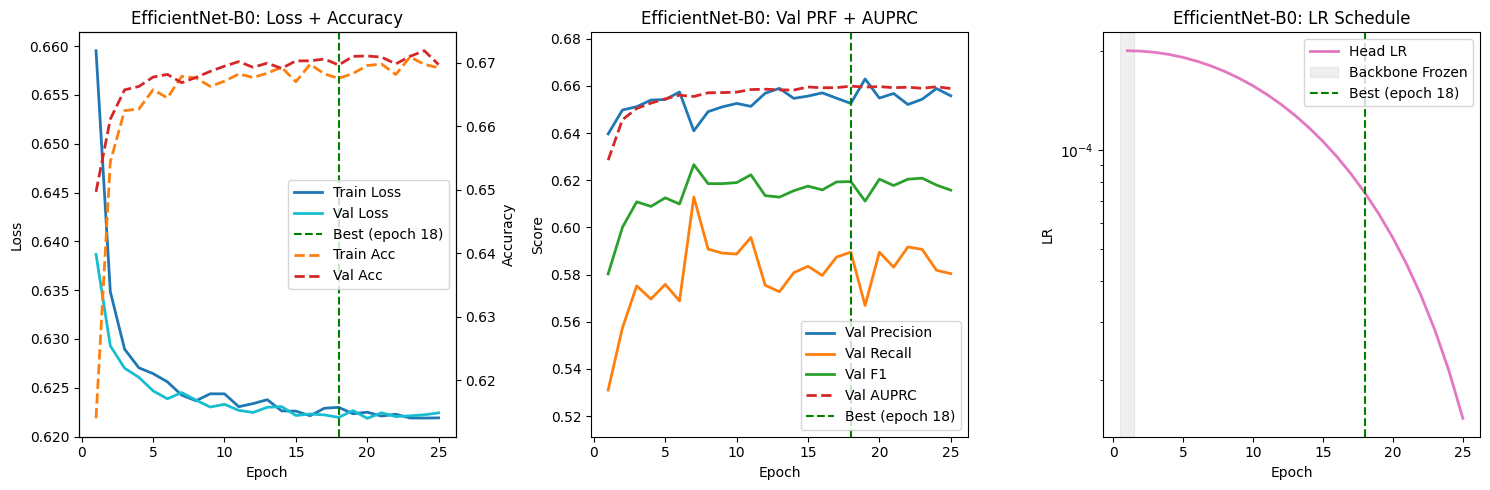

Early stopping at epoch 25 (patience 7 exceeded)


Val:   0%|          | 0/64 [00:00<?, ?it/s]

In [6]:
metrics, history = run_training_pipeline(
    model_name="EfficientNet-B0",
    model_builder=lambda: EfficientNetB0(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=True,
)

## Results


### Val Metrics

In [7]:
best_epoch = history.get('best_epoch')
if best_epoch is not None:
    idx = best_epoch - 1  # Convert epoch (1-indexed) to array index (0-indexed)

    print("\n=== Best Epoch Validation Metrics ===")
    print(f"Epoch: {best_epoch}")
    print(f"Val Loss:      {history['val_loss'][idx]:.4f}")
    print(f"Val Accuracy:  {history['val_acc'][idx]:.4f}")
    print(f"Val Precision: {history['val_precision'][idx]:.4f}")
    print(f"Val Recall:    {history['val_recall'][idx]:.4f}")
    print(f"Val F1:        {history['val_f1'][idx]:.4f}")
    if 'val_auprc' in history and history['val_auprc']:
        print(f"Val AUPRC:     {history['val_auprc'][idx]:.4f}")


=== Best Epoch Validation Metrics ===
Epoch: 18
Val Loss:      0.6220
Val Accuracy:  0.6697
Val Precision: 0.6526
Val Recall:    0.5895
Val F1:        0.6195
Val AUPRC:     0.6599


### Test Metrics

In [8]:
# plot_training_history_compact(history, model_name="EfficientNet-B0")

print("\n=== Test Results ===")
print(f"Loss:        {metrics['test_loss']:.4f}")
print(f"Accuracy:    {metrics['accuracy']:.4f}")
print(f"Precision:   {metrics['precision']:.4f}")
print(f"Recall:      {metrics['recall']:.4f}")
print(f"F1:          {metrics['f1']:.4f}")
print(f"AUPRC:       {metrics['auprc']:.4f}")


=== Test Results ===
Loss:        0.6163
Accuracy:    0.6768
Precision:   0.6650
Recall:      0.6055
F1:          0.6339
AUPRC:       0.6752


Val:   0%|          | 0/64 [00:00<?, ?it/s]

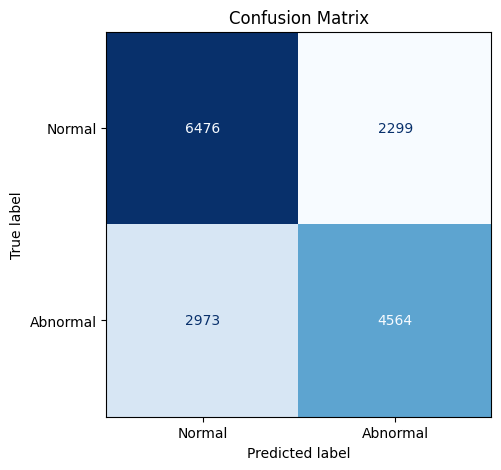

In [9]:
model = EfficientNetB0(num_classes=2, in_channels=1).to(device)
model.load_state_dict(torch.load(get_model_path("best_efficientnet_b0"), map_location=device))
criterion = torch.nn.CrossEntropyLoss()

_, _, _, _, _, test_labels, test_preds, _ = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

plot_confusion_matrix_figure(test_labels, test_preds, ["Normal", "Abnormal"])

In [10]:
import random

_, eval_transforms = get_transforms()
image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
result = predict_single_image(image_path, model, device, eval_transforms, df=df)

print("Image path:      ", image_path)
print("True label:      ", result["true_label"])
print("Predicted class: ", result["predicted_class"])
print("Probabilities:   ", result["probabilities"])

Image path:       C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays\images_005\images\00009574_010.png
True label:       normal
Predicted class:  normal
Probabilities:    {'normal': 0.5745283365249634, 'abnormal': 0.425471693277359}
